<a href="https://colab.research.google.com/github/iMba-I/Labs/blob/main/Lab4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Создание временного ряда(в7) и его визуализация



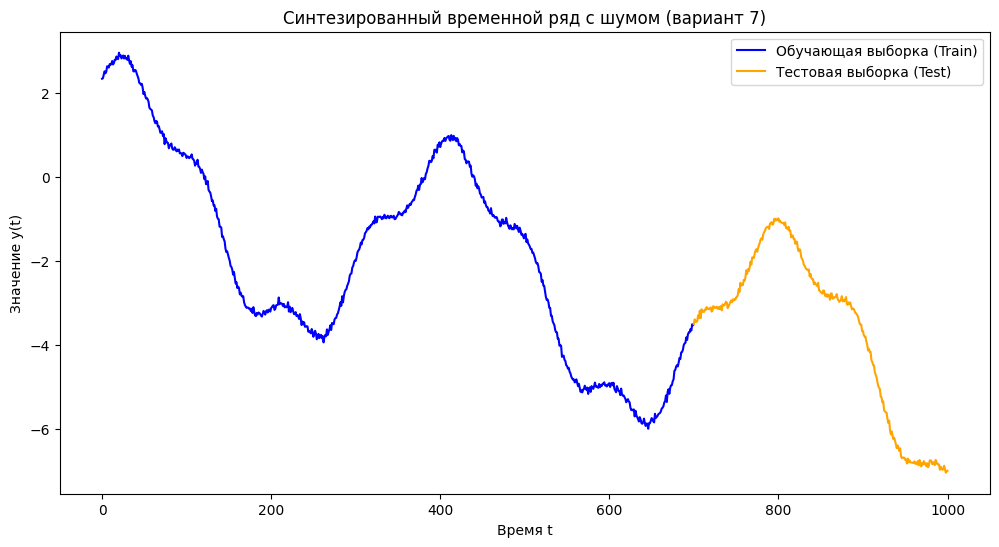

Макс разница sklearn vs numpy нормализации (train): 0.0
Макс разница sklearn vs numpy нормализации (test): 0.0


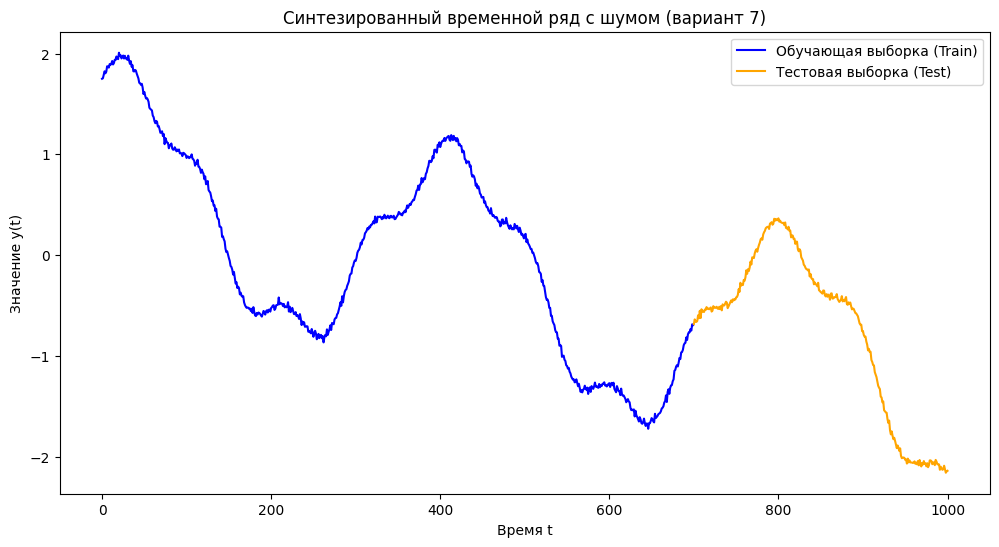

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

def generate_time_series_variant7():
    t = np.arange(0, 1001, 1)
    y = 2.5 * np.cos(0.016 * t - 0.4) + 0.5 * np.sin(0.065 * t) - 0.005 * t
    noise = np.random.normal(loc=0, scale=0.05, size=t.shape)
    y_noisy = y + noise
    return t, y_noisy


def plot_train_test(t1, y_train,t2,y_test):
    plt.figure(figsize=(12, 6))
    plt.plot(t_train, y_train, label='Обучающая выборка (Train)', color='blue')
    plt.plot(t_test, y_test, label='Тестовая выборка (Test)', color='orange')
    plt.xlabel('Время t')
    plt.ylabel('Значение y(t)')
    plt.title('Синтезированный временной ряд с шумом (вариант 7)')
    plt.legend()
    plt.show()
    return

def normalize_data(y_train, y_test):
    scaler = StandardScaler()
    y_train_scaled = scaler.fit_transform(y_train.reshape(-1,1)).flatten()
    y_test_scaled = scaler.transform(y_test.reshape(-1,1)).flatten()
    # numpy-нормализация
    mean_train = scaler.mean_[0]
    std_train = np.sqrt(scaler.var_)[0]
    y_train_scaled_np = (y_train - mean_train) / std_train
    y_test_scaled_np = (y_test - mean_train) / std_train
    print("Макс разница sklearn vs numpy нормализации (train):", np.max(np.abs(y_train_scaled - y_train_scaled_np)))
    print("Макс разница sklearn vs numpy нормализации (test):", np.max(np.abs(y_test_scaled - y_test_scaled_np)))
    return y_train_scaled, y_test_scaled, scaler

np.random.seed(42)

t, y_noisy = generate_time_series_variant7()
y_train = y_noisy[:700]
t_train = t[:700]
y_test = y_noisy[700:]
t_test = t[700:]

plot_train_test(t_train, y_train,t_test,y_test)

y_train_scaled, y_test_scaled, scaler = normalize_data(y_train, y_test)
plot_train_test(t_train, y_train_scaled,t_test,y_test_scaled)

Функция для создание датасета с заданным lookback

In [ ]:
def create_dataset(data, lookback=20):
    X, y = [], []
    data = np.array(data)
    for i in range(lookback, len(data)-1):
        X.append(data[i-lookback:i])
        y.append(data[i+1])
    return np.array(X), np.array(y)

Реализация шага RNN и LSTM

In [ ]:
def rnn_cell_forward(xt, hprev, Wxh, Whh, bh):
    z = np.dot(Wxh, xt) + np.dot(Whh, hprev) + bh
    h_next = np.tanh(z)
    return h_next

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def lstm_cell_forward(xt, hprev, cprev, params):
    Wf, Wi, Wo, Wc = params['Wf'], params['Wi'], params['Wo'], params['Wc']
    bf, bi, bo, bc = params['bf'], params['bi'], params['bo'], params['bc']

    a = np.vstack((hprev, xt))

    ft = sigmoid(np.dot(Wf, a) + bf)
    it = sigmoid(np.dot(Wi, a) + bi)
    ot = sigmoid(np.dot(Wo, a) + bo)
    c_tilde = np.tanh(np.dot(Wc, a) + bc)

    c_next = ft * cprev + it * c_tilde
    h_next = ot * np.tanh(c_next)

    return h_next, c_next

Инициализация весов сетей

In [ ]:
    lookback = 20
    X_train, y_train_targets = create_dataset(y_train_scaled, lookback=lookback)
    X_test, y_test_targets = create_dataset(y_test_scaled, lookback=lookback)
    print(f"Формы обучающего датасета: X={X_train.shape}, y={y_train_targets.shape}")
    print(f"Формы тестового датасета: X={X_test.shape}, y={y_test_targets.shape}")

    nx = 1
    nh = 5

        #LSTM
    params_lstm = {
        'Wf': np.random.randn(nh, nh + nx) * 0.5,
        'Wi': np.random.randn(nh, nh + nx) * 0.5,
        'Wo': np.random.randn(nh, nh + nx) * 0.5,
        'Wc': np.random.randn(nh, nh + nx) * 0.5,
        'bf': np.random.randn(nh, 1) * 0.1,
        'bi': np.random.randn(nh, 1) * 0.1,
        'bo': np.random.randn(nh, 1) * 0.1,
        'bc': np.random.randn(nh, 1) * 0.1,
    }

    # RNN
    Wxh = np.random.randn(nh, nx) * 0.5
    Whh = np.random.randn(nh, nh) * 0.5
    bh = np.random.randn(nh, 1) * 0.1

    # выходной
    Wout = np.random.randn(1, nh) * 0.5
    bout = np.random.randn(1, 1) * 0.1

Формы обучающего датасета: X=(679, 20), y=(679,)
Формы тестового датасета: X=(280, 20), y=(280,)


Функции предсказания для всего датасета

In [ ]:
def predict_lstm(X, params, Wout, bout):
    nh = Wout.shape[1]
    num_samples = X.shape[0]
    preds = []

    for i in range(num_samples):
        hprev = np.zeros((nh,1))
        cprev = np.zeros((nh,1))
        for j in range(X.shape[1]):
            xt = np.array([[X[i,j]]])
            hprev, cprev = lstm_cell_forward(xt, hprev, cprev, params)
        y_pred = np.dot(Wout, hprev) + bout
        preds.append(y_pred.flatten()[0])

    return np.array(preds)


def predict_rnn(X, Wxh, Whh, bh, Wout, bout):
    nh = Wxh.shape[0]
    num_samples = X.shape[0]
    preds = []

    for i in range(num_samples):
        hprev = np.zeros((nh,1))
        for j in range(X.shape[1]):
            xt = np.array([[X[i,j]]])
            hprev = rnn_cell_forward(xt, hprev, Wxh, Whh, bh)
        y_pred = np.dot(Wout, hprev) + bout
        preds.append(y_pred.flatten()[0])

    return np.array(preds)

Визуализация

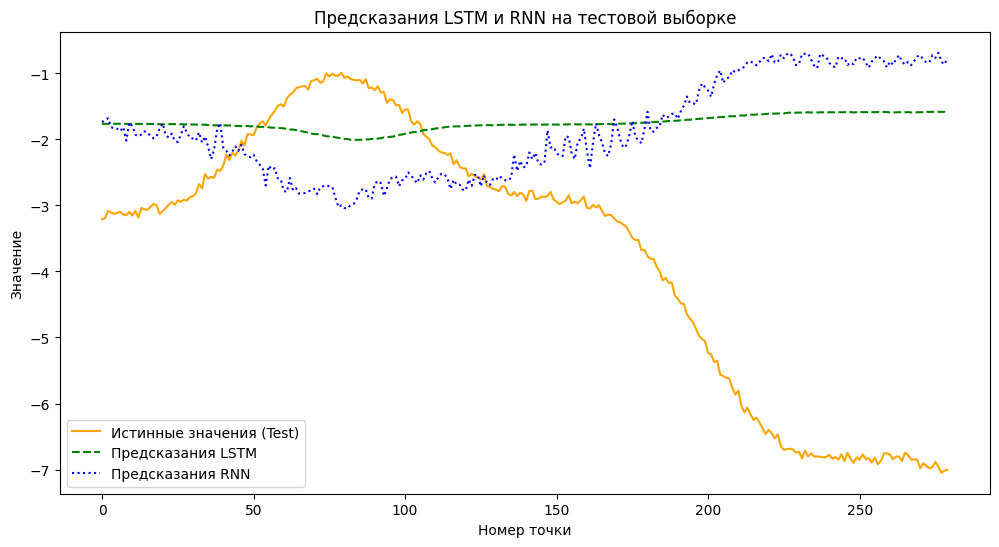

In [ ]:



    preds_lstm_scaled = predict_lstm(X_test, params_lstm, Wout, bout)
    preds_rnn_scaled = predict_rnn(X_test, Wxh, Whh, bh, Wout, bout)

    preds_lstm = preds_lstm_scaled * scaler.scale_[0] + scaler.mean_[0]
    preds_rnn = preds_rnn_scaled * scaler.scale_[0] + scaler.mean_[0]
    y_true = y_test_targets * scaler.scale_[0] + scaler.mean_[0]

    # График предсказаний и истинных значений
    plt.figure(figsize=(12,6))
    plt.plot(range(len(y_true)), y_true, label='Истинные значения (Test)', color='orange')
    plt.plot(range(len(preds_lstm)), preds_lstm, label='Предсказания LSTM', color='green', linestyle='--')
    plt.plot(range(len(preds_rnn)), preds_rnn, label='Предсказания RNN', color='blue', linestyle=':')
    plt.xlabel('Номер точки')
    plt.ylabel('Значение')
    plt.title('Предсказания LSTM и RNN на тестовой выборке')
    plt.legend()
    plt.show()


tensorflow на синтетических данных, создание и обработка данных


In [ ]:
np.random.seed(42)

t, y_noisy = generate_time_series_variant7()
y_train = y_noisy[:700]
t_train = t[:700]
y_test = y_noisy[700:]
t_test = t[700:]

y_train_scaled, y_test_scaled, scaler = normalize_data(y_train, y_test)

x_train, y_train_scaled = create_dataset(y_train_scaled,20)
x_test, y_test_scaled = create_dataset(y_test_scaled,20)

x_train = x_train.reshape((x_train.shape[0], x_train.shape[1], 1))
x_test = x_test.reshape((x_test.shape[0], x_test.shape[1], 1))

Макс разница sklearn vs numpy нормализации (train): 0.0
Макс разница sklearn vs numpy нормализации (test): 0.0


Инициализация моделей tensorflow

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, Dense
from sklearn.metrics import mean_squared_error, mean_absolute_error

lookback = 20
# Модель RNN
model_rnn = Sequential([
    SimpleRNN(32, input_shape=(lookback, 1)),
    Dense(1)
])
model_rnn.compile(optimizer='adam', loss='mse')

# Модель LSTM
model_lstm = Sequential([
    LSTM(32, input_shape=(lookback, 1)),
    Dense(1)
])

model_lstm.compile(optimizer='adam', loss='mse')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Обучение моделей

In [ ]:
epochs = 100
batch_size = 32

history_rnn = model_rnn.fit(
    x_train, y_train_scaled,
    validation_split=0.2,
    epochs=epochs,
    batch_size=batch_size,
    verbose=1
)

history_lstm = model_lstm.fit(
    x_train, y_train_scaled,
    validation_split=0.2,
    epochs=epochs,
    batch_size=batch_size,
    verbose=1
)

Epoch 1/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 0.1611 - val_loss: 0.0923
Epoch 2/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0177 - val_loss: 0.0143
Epoch 3/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0067 - val_loss: 0.0095
Epoch 4/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0035 - val_loss: 0.0053
Epoch 5/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0025 - val_loss: 0.0038
Epoch 6/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0019 - val_loss: 0.0036
Epoch 7/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0018 - val_loss: 0.0035
Epoch 8/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0016 - val_loss: 0.0028
Epoch 9/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0016 - val_loss: 0.0035
Epoch 10/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0017 - val_loss: 0.0026
Epoch 11/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0016 - val_loss: 0.0041
Epoch 12/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0

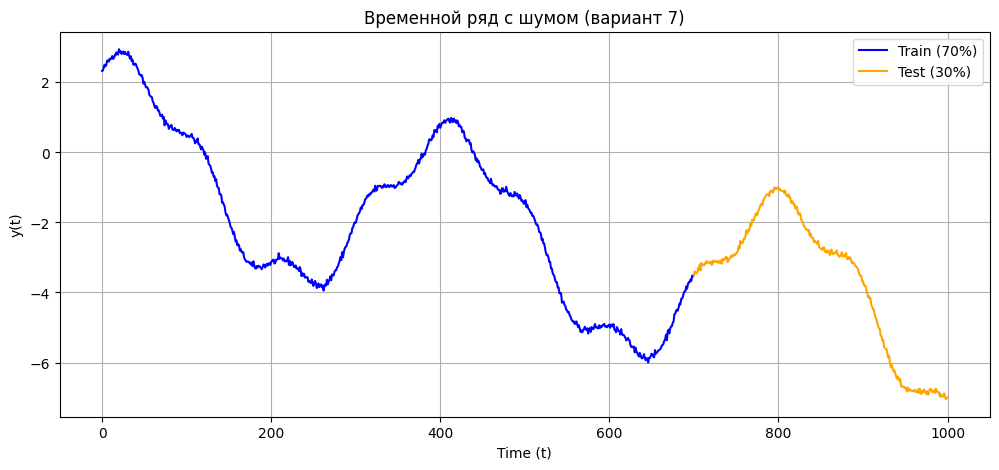

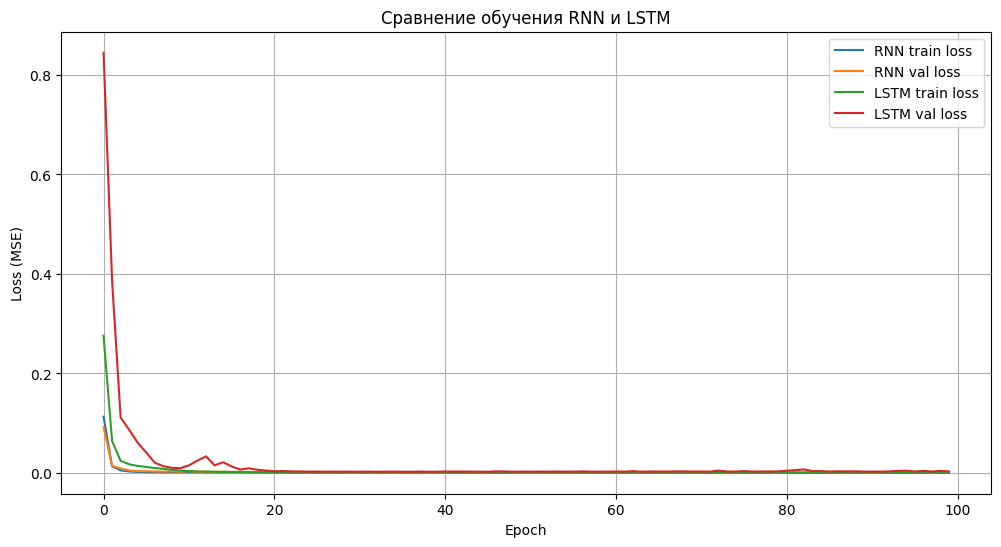

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


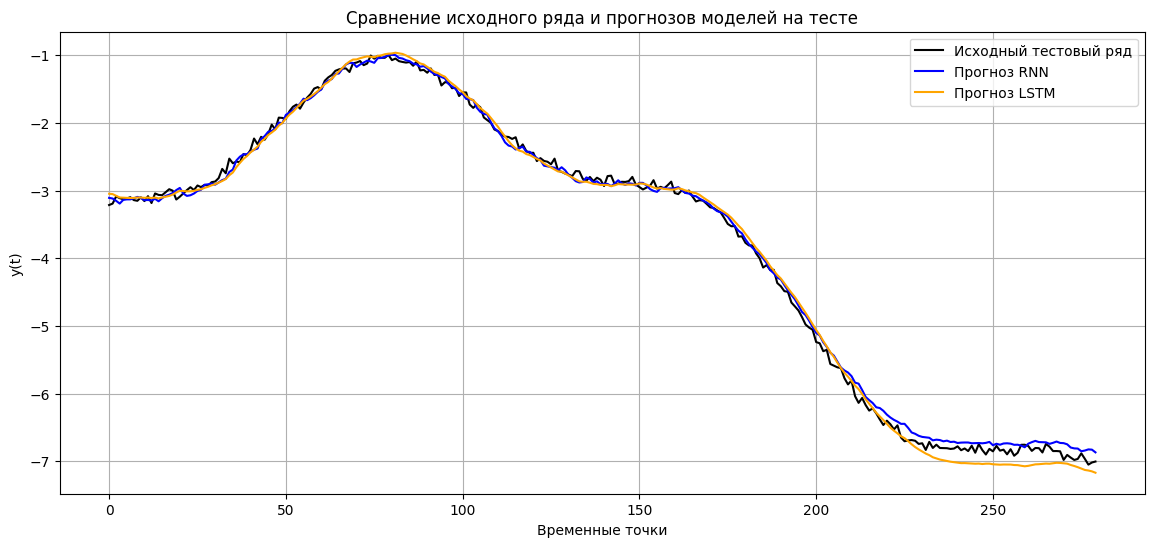

RNN MSE: 0.00824, MAE: 0.07303
LSTM MSE: 0.01266, MAE: 0.08892


In [ ]:

# 6. Визуализация процесса обучения
plt.figure(figsize=(12, 6))
plt.plot(history_rnn.history['loss'], label='RNN train loss')
plt.plot(history_rnn.history['val_loss'], label='RNN val loss')
plt.plot(history_lstm.history['loss'], label='LSTM train loss')
plt.plot(history_lstm.history['val_loss'], label='LSTM val loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Сравнение обучения RNN и LSTM')
plt.legend()
plt.grid(True)
plt.show()

# 7. Предсказание на тестовой выборке
y_pred_rnn_scaled = model_rnn.predict(x_test).flatten()
y_pred_lstm_scaled = model_lstm.predict(x_test).flatten()

def inverse_transform(data_scaled, mean, std):
    return data_scaled * std + mean

y_test_orig = inverse_transform(y_test_scaled, scaler.mean_[0], scaler.scale_[0])
y_pred_rnn_orig = inverse_transform(y_pred_rnn_scaled, scaler.mean_[0], scaler.scale_[0])
y_pred_lstm_orig = inverse_transform(y_pred_lstm_scaled, scaler.mean_[0], scaler.scale_[0])

# 8. График предсказаний и истинных значений
plt.figure(figsize=(14, 6))
plt.plot(y_test_orig, label='Исходный тестовый ряд', color='black')
plt.plot(y_pred_rnn_orig, label='Прогноз RNN', color='blue')
plt.plot(y_pred_lstm_orig, label='Прогноз LSTM', color='orange')
plt.xlabel('Временные точки')
plt.ylabel('y(t)')
plt.title('Сравнение исходного ряда и прогнозов моделей на тесте')
plt.legend()
plt.grid(True)
plt.show()

# 9. Вычисление метрик качества
mse_rnn = mean_squared_error(y_test_orig, y_pred_rnn_orig)
mae_rnn = mean_absolute_error(y_test_orig, y_pred_rnn_orig)

mse_lstm = mean_squared_error(y_test_orig, y_pred_lstm_orig)
mae_lstm = mean_absolute_error(y_test_orig, y_pred_lstm_orig)

print(f"RNN MSE: {mse_rnn:.5f}, MAE: {mae_rnn:.5f}")
print(f"LSTM MSE: {mse_lstm:.5f}, MAE: {mae_lstm:.5f}")


Загрузка и визуализация первичных данных

        Date  Temp
0 1981-01-01  20.7
1 1981-01-02  17.9
2 1981-01-03  18.8
3 1981-01-04  14.6
4 1981-01-05  15.8


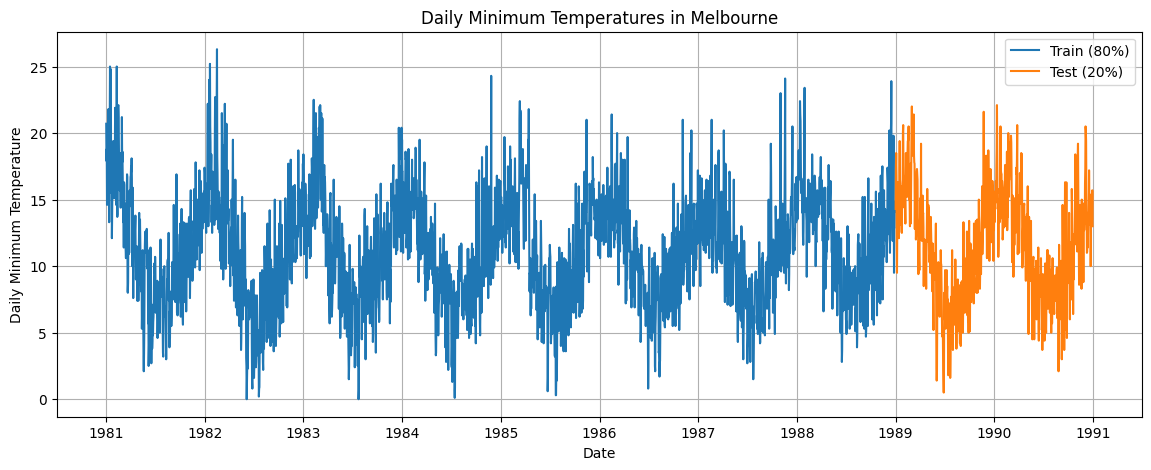

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, Dense
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

#  Загрузка и обработка данных
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv'
df = pd.read_csv(url, parse_dates=['Date'])
print(df.head())

data = df['Temp'].values.reshape(-1, 1)

split_idx = int(len(data) * 0.8)
train_data = data[:split_idx]
test_data = data[split_idx:]

#  Графики начальных данных
plt.figure(figsize=(14, 5))
plt.plot(df['Date'][:split_idx], train_data, label='Train (80%)')
plt.plot(df['Date'][split_idx:], test_data, label='Test (20%)')
plt.xlabel('Date')
plt.ylabel('Daily Minimum Temperature')
plt.title('Daily Minimum Temperatures in Melbourne')
plt.legend()
plt.grid(True)
plt.show()

Обработка данных и создание моделей


--- Lookback = 2 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step
RNN MSE: 8.0293, MAE: 2.2297
LSTM MSE: 8.0652, MAE: 2.2331


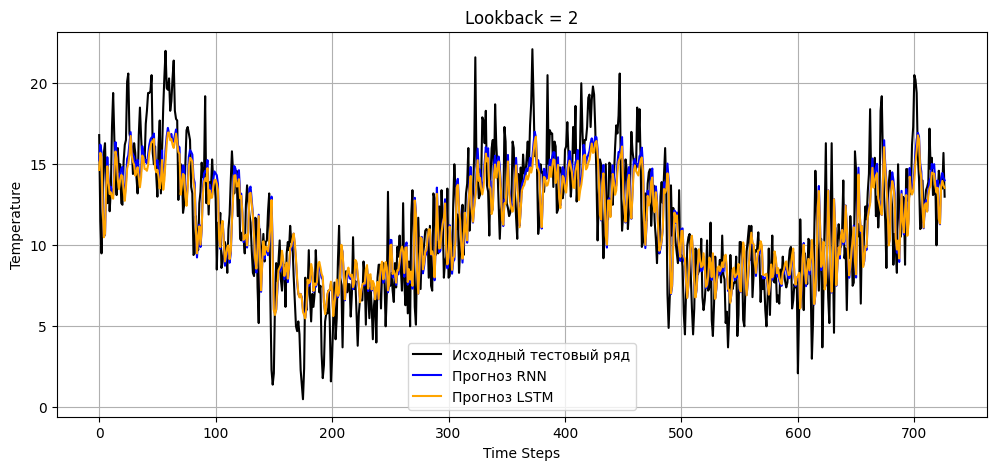


--- Lookback = 4 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step
RNN MSE: 7.4293, MAE: 2.1391
LSTM MSE: 7.1988, MAE: 2.1133


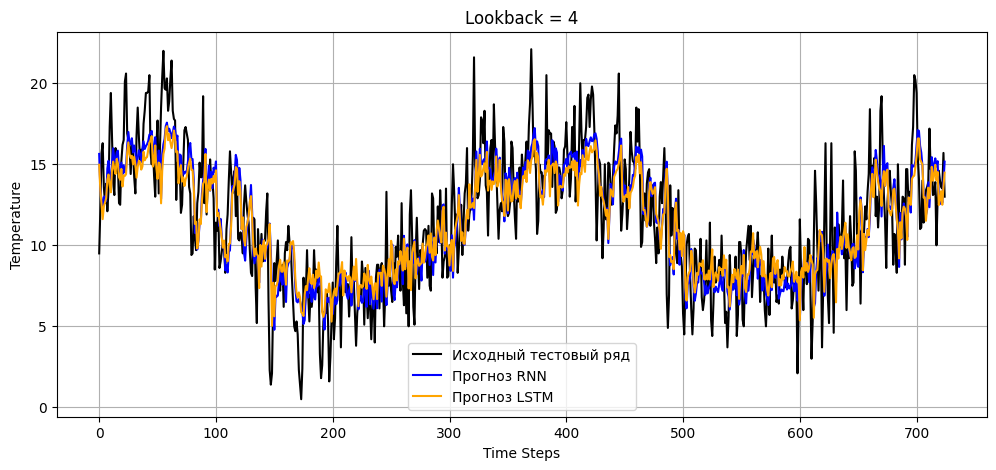


--- Lookback = 8 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step
RNN MSE: 10.7645, MAE: 2.5752
LSTM MSE: 9.7440, MAE: 2.4695


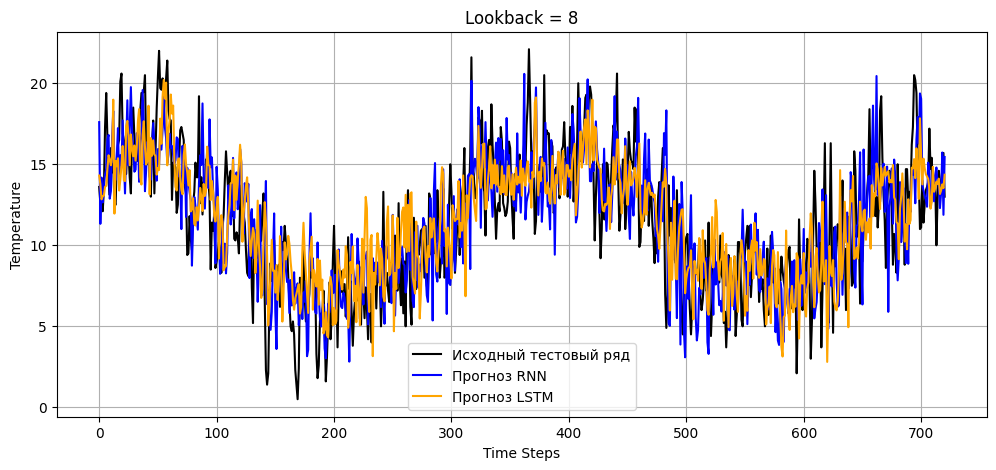


--- Lookback = 16 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step
RNN MSE: 11.8496, MAE: 2.7200
LSTM MSE: 10.3179, MAE: 2.5661


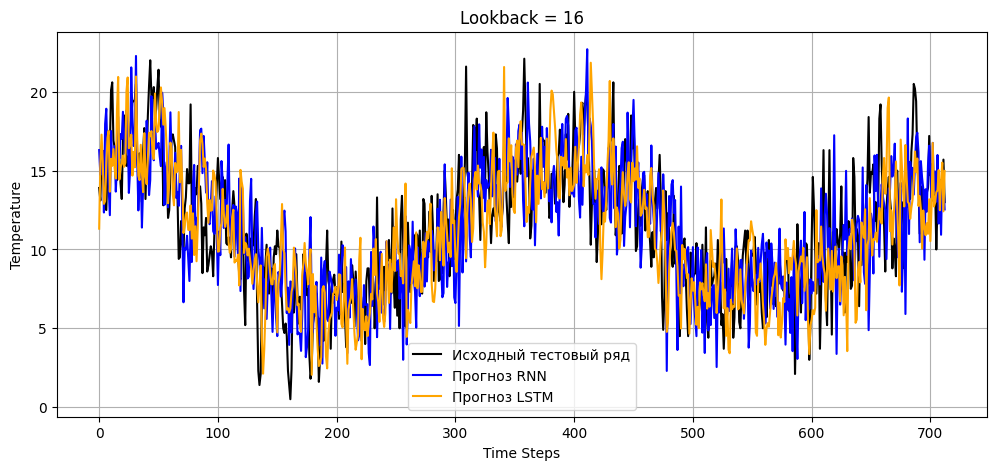


--- Lookback = 32 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step
RNN MSE: 10.4360, MAE: 2.5805
LSTM MSE: 10.9683, MAE: 2.6170


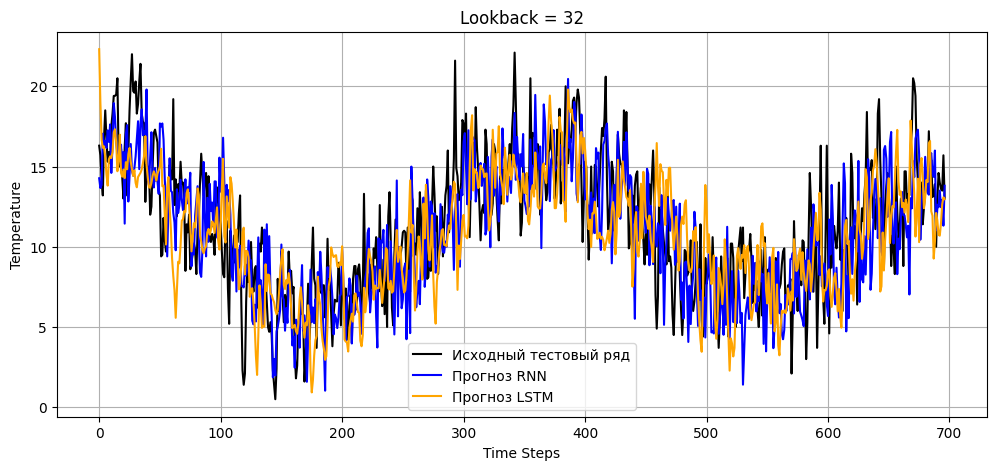


Лучший lookback по MSE для LSTM: 4
Метрики для лучшего lookback:
RNN  — MSE: 7.4293, MAE: 2.1391
LSTM — MSE: 7.1988, MAE: 2.1133


In [10]:
scaler = StandardScaler()
train_scaled = scaler.fit_transform(train_data)
test_scaled = scaler.transform(test_data)

lookbacks = [2, 4, 8, 16, 32]
epochs = 100
batch_size = 32

results = {}

for lookback in lookbacks:
    print(f"\n--- Lookback = {lookback} ---")

    X_train, y_train = create_dataset(train_scaled, lookback)
    X_test, y_test = create_dataset(test_scaled, lookback)

    X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
    X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

    model_rnn = Sequential([
        SimpleRNN(64, return_sequences=True, input_shape=(lookback, 1)),
        SimpleRNN(32),
        Dense(1)
    ])
    model_rnn.compile(optimizer='adam', loss='mse')

    model_lstm = Sequential([
        LSTM(64, return_sequences=True, input_shape=(lookback, 1)),
        LSTM(32),
        Dense(1)
    ])
    model_lstm.compile(optimizer='adam', loss='mse')

    history_rnn = model_rnn.fit(
        X_train, y_train,
        validation_split=0.2,
        epochs=epochs,
        batch_size=batch_size,
        verbose=0
    )

    history_lstm = model_lstm.fit(
        X_train, y_train,
        validation_split=0.2,
        epochs=epochs,
        batch_size=batch_size,
        verbose=0
    )


    y_pred_rnn_scaled = model_rnn.predict(X_test).flatten()
    y_pred_lstm_scaled = model_lstm.predict(X_test).flatten()


    y_test_orig = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()
    y_pred_rnn_orig = scaler.inverse_transform(y_pred_rnn_scaled.reshape(-1, 1)).flatten()
    y_pred_lstm_orig = scaler.inverse_transform(y_pred_lstm_scaled.reshape(-1, 1)).flatten()

    mse_rnn = mean_squared_error(y_test_orig, y_pred_rnn_orig)
    mae_rnn = mean_absolute_error(y_test_orig, y_pred_rnn_orig)
    mse_lstm = mean_squared_error(y_test_orig, y_pred_lstm_orig)
    mae_lstm = mean_absolute_error(y_test_orig, y_pred_lstm_orig)

    print(f"RNN MSE: {mse_rnn:.4f}, MAE: {mae_rnn:.4f}")
    print(f"LSTM MSE: {mse_lstm:.4f}, MAE: {mae_lstm:.4f}")

    results[lookback] = {
        'y_test': y_test_orig,
        'y_pred_rnn': y_pred_rnn_orig,
        'y_pred_lstm': y_pred_lstm_orig,
        'mse_rnn': mse_rnn,
        'mae_rnn': mae_rnn,
        'mse_lstm': mse_lstm,
        'mae_lstm': mae_lstm
    }

    plt.figure(figsize=(12, 5))
    plt.plot(y_test_orig, label='Исходный тестовый ряд', color='black')
    plt.plot(y_pred_rnn_orig, label='Прогноз RNN', color='blue')
    plt.plot(y_pred_lstm_orig, label='Прогноз LSTM', color='orange')
    plt.title(f'Lookback = {lookback}')
    plt.xlabel('Time Steps')
    plt.ylabel('Temperature')
    plt.legend()
    plt.grid(True)
    plt.show()

# Определение лучшего lookback по MSE (LSTM)
best_lookback = min(results, key=lambda k: results[k]['mse_lstm'])

print(f"\nЛучший lookback по MSE для LSTM: {best_lookback}")
print(f"Метрики для лучшего lookback:")
print(f"RNN  — MSE: {results[best_lookback]['mse_rnn']:.4f}, MAE: {results[best_lookback]['mae_rnn']:.4f}")
print(f"LSTM — MSE: {results[best_lookback]['mse_lstm']:.4f}, MAE: {results[best_lookback]['mae_lstm']:.4f}")

Обучение моделей


In [7]:

    history_rnn = model_rnn.fit(
        X_train, y_train,
        validation_split=0.2,
        epochs=epochs,
        batch_size=batch_size,
        verbose=0
    )

    history_lstm = model_lstm.fit(
        X_train, y_train,
        validation_split=0.2,
        epochs=epochs,
        batch_size=batch_size,
        verbose=0
    )

Предсказания и визуализация

22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 68ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 116ms/step
RNN MSE: 10.8216, MAE: 2.5768
LSTM MSE: 11.0697, MAE: 2.6189


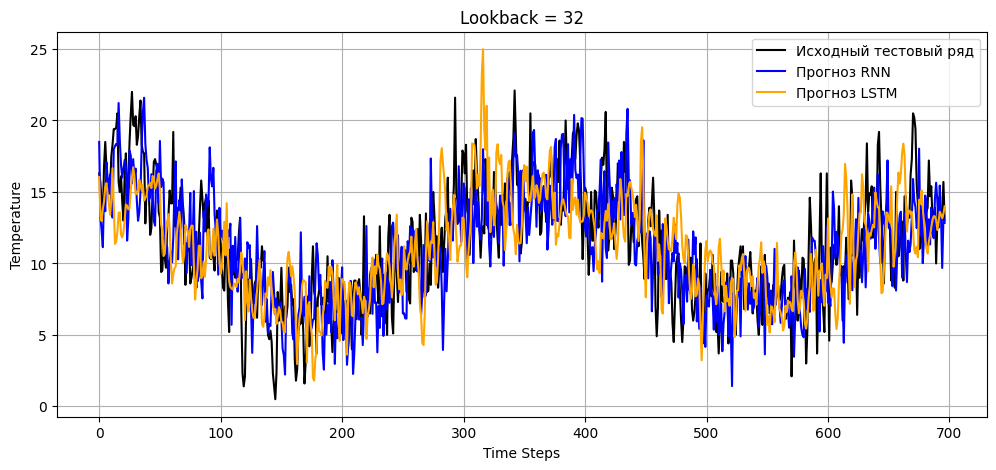


Лучший lookback по MSE для LSTM: 32
Метрики для лучшего lookback:
RNN  — MSE: 10.8216, MAE: 2.5768
LSTM — MSE: 11.0697, MAE: 2.6189


In [9]:

    y_pred_rnn_scaled = model_rnn.predict(X_test).flatten()
    y_pred_lstm_scaled = model_lstm.predict(X_test).flatten()


    y_test_orig = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()
    y_pred_rnn_orig = scaler.inverse_transform(y_pred_rnn_scaled.reshape(-1, 1)).flatten()
    y_pred_lstm_orig = scaler.inverse_transform(y_pred_lstm_scaled.reshape(-1, 1)).flatten()

    mse_rnn = mean_squared_error(y_test_orig, y_pred_rnn_orig)
    mae_rnn = mean_absolute_error(y_test_orig, y_pred_rnn_orig)
    mse_lstm = mean_squared_error(y_test_orig, y_pred_lstm_orig)
    mae_lstm = mean_absolute_error(y_test_orig, y_pred_lstm_orig)

    print(f"RNN MSE: {mse_rnn:.4f}, MAE: {mae_rnn:.4f}")
    print(f"LSTM MSE: {mse_lstm:.4f}, MAE: {mae_lstm:.4f}")

    results[lookback] = {
        'y_test': y_test_orig,
        'y_pred_rnn': y_pred_rnn_orig,
        'y_pred_lstm': y_pred_lstm_orig,
        'mse_rnn': mse_rnn,
        'mae_rnn': mae_rnn,
        'mse_lstm': mse_lstm,
        'mae_lstm': mae_lstm
    }

    plt.figure(figsize=(12, 5))
    plt.plot(y_test_orig, label='Исходный тестовый ряд', color='black')
    plt.plot(y_pred_rnn_orig, label='Прогноз RNN', color='blue')
    plt.plot(y_pred_lstm_orig, label='Прогноз LSTM', color='orange')
    plt.title(f'Lookback = {lookback}')
    plt.xlabel('Time Steps')
    plt.ylabel('Temperature')
    plt.legend()
    plt.grid(True)
    plt.show()

# Определение лучшего lookback по MSE (LSTM)
best_lookback = min(results, key=lambda k: results[k]['mse_lstm'])

print(f"\nЛучший lookback по MSE для LSTM: {best_lookback}")
print(f"Метрики для лучшего lookback:")
print(f"RNN  — MSE: {results[best_lookback]['mse_rnn']:.4f}, MAE: {results[best_lookback]['mae_rnn']:.4f}")
print(f"LSTM — MSE: {results[best_lookback]['mse_lstm']:.4f}, MAE: {results[best_lookback]['mae_lstm']:.4f}")


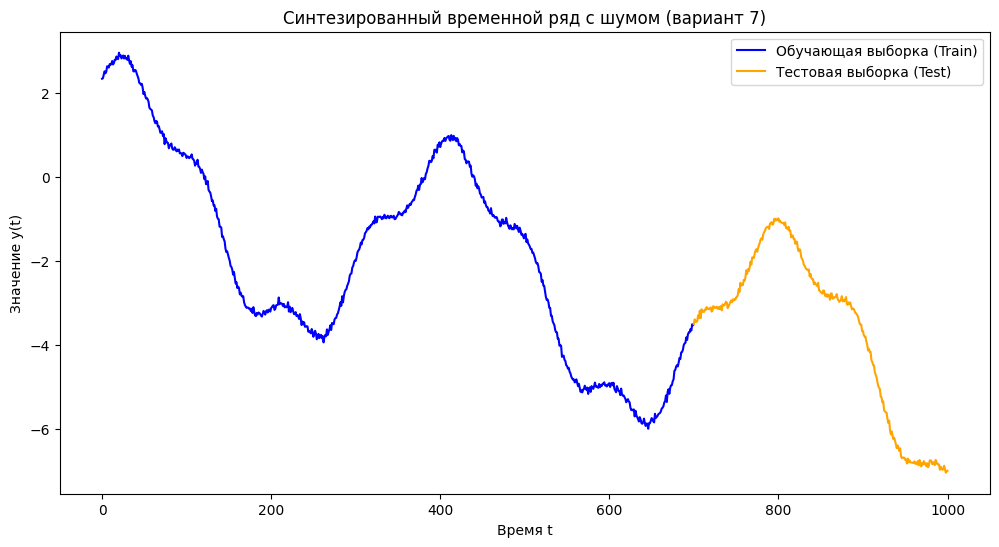

Макс разница sklearn vs numpy нормализации (train): 0.0
Макс разница sklearn vs numpy нормализации (test): 0.0
Формы обучающего датасета: X=(679, 20), y=(679,)
Формы тестового датасета: X=(280, 20), y=(280,)


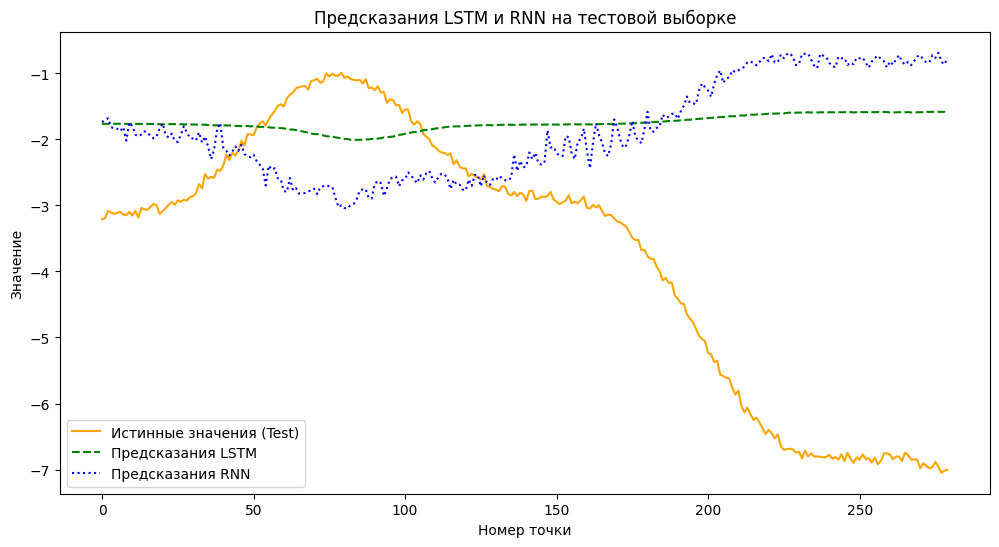

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# --- 1. Синтез временного ряда вариант 7 ---

def generate_time_series_variant7():
    t = np.arange(0, 1001, 1)
    y = 2.5 * np.cos(0.016 * t - 0.4) + 0.5 * np.sin(0.065 * t) - 0.005 * t
    noise = np.random.normal(loc=0, scale=0.05, size=t.shape)
    y_noisy = y + noise
    return t, y_noisy

def plot_train_test(t, y_noisy):
    y_train = y_noisy[:700]
    y_test = y_noisy[700:]
    plt.figure(figsize=(12, 6))
    plt.plot(t[:700], y_train, label='Обучающая выборка (Train)', color='blue')
    plt.plot(t[700:], y_test, label='Тестовая выборка (Test)', color='orange')
    plt.xlabel('Время t')
    plt.ylabel('Значение y(t)')
    plt.title('Синтезированный временной ряд с шумом (вариант 7)')
    plt.legend()
    plt.show()
    return y_train, y_test

def normalize_data(y_train, y_test):
    scaler = StandardScaler()
    y_train_scaled = scaler.fit_transform(y_train.reshape(-1,1)).flatten()
    y_test_scaled = scaler.transform(y_test.reshape(-1,1)).flatten()
    # numpy-нормализация
    mean_train = scaler.mean_[0]
    std_train = np.sqrt(scaler.var_)[0]
    y_train_scaled_np = (y_train - mean_train) / std_train
    y_test_scaled_np = (y_test - mean_train) / std_train
    print("Макс разница sklearn vs numpy нормализации (train):", np.max(np.abs(y_train_scaled - y_train_scaled_np)))
    print("Макс разница sklearn vs numpy нормализации (test):", np.max(np.abs(y_test_scaled - y_test_scaled_np)))
    return y_train_scaled, y_test_scaled, scaler

# --- 2. Функция для создания обучающих примеров скользящим окном ---

def create_dataset(data, lookback=20):
    X, y = [], []
    data = np.array(data)
    for i in range(lookback, len(data)-1):
        X.append(data[i-lookback:i])
        y.append(data[i+1])
    return np.array(X), np.array(y)

# --- 3. Шаг RNN ---

def rnn_cell_forward(xt, hprev, Wxh, Whh, bh):
    z = np.dot(Wxh, xt) + np.dot(Whh, hprev) + bh
    h_next = np.tanh(z)
    return h_next

# --- 4. Шаг LSTM ---

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def lstm_cell_forward(xt, hprev, cprev, params):
    Wf, Wi, Wo, Wc = params['Wf'], params['Wi'], params['Wo'], params['Wc']
    bf, bi, bo, bc = params['bf'], params['bi'], params['bo'], params['bc']

    a = np.vstack((hprev, xt))  # конкатенация

    ft = sigmoid(np.dot(Wf, a) + bf)  # forget gate
    it = sigmoid(np.dot(Wi, a) + bi)  # input gate
    ot = sigmoid(np.dot(Wo, a) + bo)  # output gate
    c_tilde = np.tanh(np.dot(Wc, a) + bc)  # кандидат

    c_next = ft * cprev + it * c_tilde  # новое состояние ячейки
    h_next = ot * np.tanh(c_next)       # новое скрытое состояние

    return h_next, c_next

# --- Функция предсказания для всего датасета по LSTM ---

def predict_lstm(X, params, Wout, bout):
    nh = Wout.shape[1]
    num_samples = X.shape[0]
    preds = []

    for i in range(num_samples):
        hprev = np.zeros((nh,1))
        cprev = np.zeros((nh,1))
        for j in range(X.shape[1]):
            xt = np.array([[X[i,j]]])
            hprev, cprev = lstm_cell_forward(xt, hprev, cprev, params)
        y_pred = np.dot(Wout, hprev) + bout
        preds.append(y_pred.flatten()[0])

    return np.array(preds)

# --- Функция предсказания для всего датасета по RNN ---

def predict_rnn(X, Wxh, Whh, bh, Wout, bout):
    nh = Wxh.shape[0]
    num_samples = X.shape[0]
    preds = []

    for i in range(num_samples):
        hprev = np.zeros((nh,1))
        for j in range(X.shape[1]):
            xt = np.array([[X[i,j]]])
            hprev = rnn_cell_forward(xt, hprev, Wxh, Whh, bh)
        y_pred = np.dot(Wout, hprev) + bout
        preds.append(y_pred.flatten()[0])

    return np.array(preds)

# --- Демонстрация работы ---

def main():
    np.random.seed(42)

    # Генерация и визуализация временного ряда
    t, y_noisy = generate_time_series_variant7()
    y_train, y_test = plot_train_test(t, y_noisy)

    # Нормализация
    y_train_scaled, y_test_scaled, scaler = normalize_data(y_train, y_test)

    # Формирование обучающего и тестового датасетов
    lookback = 20
    X_train, y_train_targets = create_dataset(y_train_scaled, lookback=lookback)
    X_test, y_test_targets = create_dataset(y_test_scaled, lookback=lookback)
    print(f"Формы обучающего датасета: X={X_train.shape}, y={y_train_targets.shape}")
    print(f"Формы тестового датасета: X={X_test.shape}, y={y_test_targets.shape}")

    nx = 1
    nh = 5

        # Инициализация параметров LSTM
        # Инициализация параметров LSTM с большим разбросом
    params_lstm = {
        'Wf': np.random.randn(nh, nh + nx) * 0.5,
        'Wi': np.random.randn(nh, nh + nx) * 0.5,
        'Wo': np.random.randn(nh, nh + nx) * 0.5,
        'Wc': np.random.randn(nh, nh + nx) * 0.5,
        'bf': np.random.randn(nh, 1) * 0.1,
        'bi': np.random.randn(nh, 1) * 0.1,
        'bo': np.random.randn(nh, 1) * 0.1,
        'bc': np.random.randn(nh, 1) * 0.1,
    }

    # Инициализация параметров RNN с большим разбросом
    Wxh = np.random.randn(nh, nx) * 0.5
    Whh = np.random.randn(nh, nh) * 0.5
    bh = np.random.randn(nh, 1) * 0.1

    # Веса и смещение линейного слоя выхода (nh -> 1)
    Wout = np.random.randn(1, nh) * 0.5
    bout = np.random.randn(1, 1) * 0.1

    # Предсказания на тестовой выборке
    preds_lstm_scaled = predict_lstm(X_test, params_lstm, Wout, bout)
    preds_rnn_scaled = predict_rnn(X_test, Wxh, Whh, bh, Wout, bout)

    # Обратное преобразование (де-нормализация)
    preds_lstm = preds_lstm_scaled * scaler.scale_[0] + scaler.mean_[0]
    preds_rnn = preds_rnn_scaled * scaler.scale_[0] + scaler.mean_[0]
    y_true = y_test_targets * scaler.scale_[0] + scaler.mean_[0]

    # График предсказаний и истинных значений
    plt.figure(figsize=(12,6))
    plt.plot(range(len(y_true)), y_true, label='Истинные значения (Test)', color='orange')
    plt.plot(range(len(preds_lstm)), preds_lstm, label='Предсказания LSTM', color='green', linestyle='--')
    plt.plot(range(len(preds_rnn)), preds_rnn, label='Предсказания RNN', color='blue', linestyle=':')
    plt.xlabel('Номер точки')
    plt.ylabel('Значение')
    plt.title('Предсказания LSTM и RNN на тестовой выборке')
    plt.legend()
    plt.show()

if __name__ == "__main__":
    main()
